Stoichiometry matrix:
 [[-1.   0.5  0. ]
 [ 1.  -0.5  0. ]
 [-1.  -2.   1. ]]
Inlet conditions:
 [1, 0.0, 0.0, 423.15]


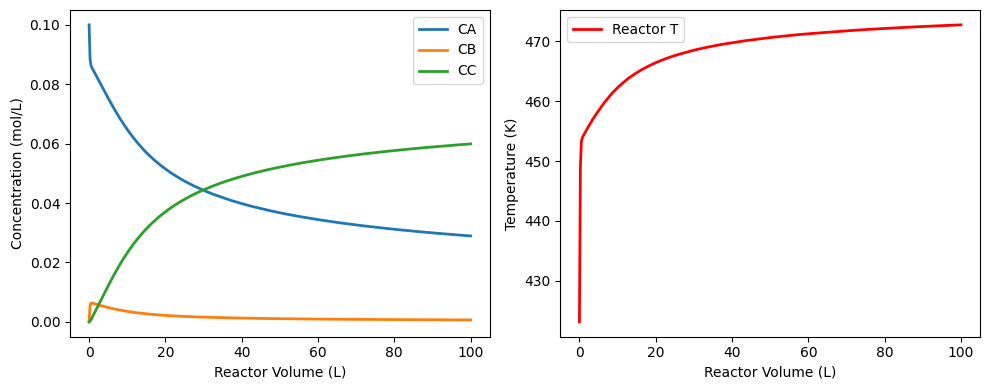

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Reactor information, input values, parameters
V = 100            # Reactor Volume (L)
FA0 = 1            # Initial molar flow rate of A (mol/min)
CA0 = 0.1          # Initial concentration of A (mol/L)
T0 = 150 + 273.15  # Inlet Temperature (K)
R_gas = 0.008314   # Gas constant (kJ/mol*K)

# Thermodynamic parameters
CP = np.array([0.09, 0.09, 0.18])     # CPA, CPB, CPC
Hrxn = np.array([-20, 20, 60])        # H1A, H2A, H3C. Basis = A, A, C.

# Kinetic parameters
k1A0, E1, TE1 = 50, 8, 350            # Basis = A
KCA0, H1A, TKCA = 10, -20, 315        # Basis = A
k3C0, E3, TE3 = 4000, 4, 310          # Basis = C

# Stoichiometry Matrix
nu = np.array([[-1, 1/2, 0], [1, -1/2, 0], [-1, -2, 1]])

# Initial Conditions
CT0 = CA0
initial_conditions = [FA0, 0.0, 0.0, T0]

print("Stoichiometry matrix:\n", nu)
print("Inlet conditions:\n", initial_conditions)

# PFR design equations
def PFR(V_step, y):
    F = y[:3]  # FA, FB, FC
    T = y[3]   # Temperature
    Ftot = np.sum(F)

    # Gas phase concentration equations
    CA, CB, CC = CT0 * (F / Ftot) * (T0 / T)

    # temperature dependent quantities (Arrhenius & Van 't Hoff)
    k1A = k1A0 * np.exp((E1 / R_gas) * (1 / TE1 - 1 / T))
    k3C = k3C0 * np.exp((E3 / R_gas) * (1 / TE3 - 1 / T))
    KCA = KCA0 * np.exp((H1A / R_gas) * (1 / TKCA - 1 / T))

    r = np.array([k1A * CA**2, (k1A / KCA) * CB, k3C * CB**2 * CA])

    # mole and energy balances
    rnet = np.dot(nu.T, r)
    Qg = np.dot(-Hrxn, r)
    dTdV = Qg / np.dot(F, CP)

    return [*rnet, dTdV]

# run the simulation
V_span = [0, V]
V_eval = np.linspace(0, V, 400)
sol = solve_ivp(PFR, V_span, initial_conditions, t_eval=V_eval)

# extract the data
pfrvol = sol.t
FA, FB, FC, T = sol.y
Ftot_profile = FA + FB + FC

# Calculate concentration profiles across all steps simultaneously
C = CT0 * (sol.y[:3] / Ftot_profile) * (T0 / T)

# Plot
plt.figure(figsize=(10, 4))

# Plot 1: Concentrations vs Volume
plt.subplot(1, 2, 1)
labels = ["CA", "CB", "CC"]
for i, label in enumerate(labels):
    plt.plot(pfrvol, C[i], label=label, lw=2)
plt.xlabel("Reactor Volume (L)")
plt.ylabel("Concentration (mol/L)")
plt.legend()

# Plot 2: Temperature Profile vs Volume
plt.subplot(1, 2, 2)
plt.plot(pfrvol, T, "r-", label="Reactor T", lw=2)
plt.xlabel("Reactor Volume (L)")
plt.ylabel("Temperature (K)")
plt.legend()

plt.tight_layout()
plt.show()